## Data from World Happiness Report

The World Happiness Report is an annual publication of the United Nations Sustainable Development Solutions Network. It contains articles, and rankings of national happiness based on respondent ratings of their own lives, which the report also correlates with various life factors.

In this notebook we will explore the happiness of different countries and the features associated.
The datasets that we will use are available in *Data*: **happiness2020.pkl** and **countries_info.csv**.

Although the features are self-explanatory, here a summary: 

**happiness2020.pkl**
* country: *Name of the country*
* happiness_score: *Happiness score*
* social_support: *Social support (mitigation the effects of inequality)*
* healthy_life_expectancy: *Healthy Life Expectancy*
* freedom_of_choices: *Freedom to make life choices*
* generosity: *Generosity (charity, volunteers)*
* perception_of_corruption: *Corruption Perception*
* world_region: *Area of the world of the country*

**countries_info.csv**
* country_name: *Name of the country*
* area: *Area in sq mi*
* population: *Number of people*
* literacy: *Literacy percentage*

In [1]:
!head Data/happiness2020.csv

country,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region
Afghanistan,2.566900015,0.470366955,52.59000015,0.39657300700000003,-0.0964294,0.9336865540000001,South Asia
Albania,4.882699966000001,0.671070457,68.70813751,0.7819942240000001,-0.042309489000000006,0.896303713,Central and Eastern Europe
Algeria,5.005099773,0.8033851390000001,65.90517426,0.46661090899999996,-0.121105164,0.7354851370000001,Middle East and North Africa
Argentina,5.974699974,0.900567949,68.80380249,0.831132412,-0.194913864,0.8420098420000001,Latin America and Caribbean
Armenia,4.676799774,0.7574794290000001,66.75065613,0.7120178340000001,-0.13877961,0.7735447879999999,Commonwealth of Independent States
Australia,7.222799778,0.9448546170000001,73.60453796,0.915431738,0.19046016,0.41516912,North America and ANZ
Austria,7.294199944,0.9280458690000001,73.00250244,0.899989486,0.085429221,0.49995487899999996,Western Europe
Azerbaijan,5.164800167,0.

In [2]:
import pandas as pd
%matplotlib inline

DATA_FOLDER = 'Data/'

HAPPINESS_DATASET = DATA_FOLDER+"happiness2020.csv"
COUNTRIES_DATASET = DATA_FOLDER+"countries_info.csv"

## Task 1: Load the data

Load the 2 datasets in Pandas dataframes (called *happiness* and *countries*), and show the first rows.


**Hint**: Use the correct reader and verify the data has the expected format.

In [3]:
# Write your code here
countries = pd.read_csv(COUNTRIES_DATASET, index_col='country_name')
countries.index.name = 'country'
happiness = pd.read_csv(HAPPINESS_DATASET, index_col='country')

## Task 2: Let's merge the data

Create a dataframe called *country_features* by merging *happiness* and *countries*. A row of this dataframe must describe all the features that we have about a country.

**Hint**: Verify that all the rows are in the final dataframe.

In [4]:
# Write your code here
happiness.index = happiness.index.map(str.lower)
merged_data = happiness.join(countries, how='outer')

## Task 3: Where are people happier?

Print the top 10 countries based on their happiness score (higher is better).

In [5]:
def top(df, column, n=5):
    return df.sort_values(by=column, ascending=False)[:n]

In [6]:
# Write your code here
top(merged_data, "happiness_score", 10)

,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region,area,population,literacy
country,,,,,,,,,,
finland,7.8087,0.954330,71.900825,0.949172,-0.059482,0.195445,Western Europe,338145,5231372,"100,0"
denmark,7.6456,0.955991,72.402504,0.951444,0.066202,0.168489,Western Europe,43094,5450661,"100,0"
switzerland,7.5599,0.942847,74.102448,0.921337,0.105911,0.303728,Western Europe,41290,7523934,"99,0"
iceland,7.5045,0.974670,73.000000,0.948892,0.246944,0.711710,Western Europe,103000,299388,"99,9"
norway,7.4880,0.952487,73.200783,0.955750,0.134533,0.263218,Western Europe,323802,4610820,"100,0"
netherlands,7.4489,0.939139,72.300919,0.908548,0.207612,0.364717,Western Europe,41526,16491461,"99,0"
sweden,7.3535,0.926311,72.600769,0.939144,0.111615,0.250880,Western Europe,449964,9016596,"99,0"
new zealand,7.2996,0.949119,73.202629,0.936217,0.191598,0.221139,North America and ANZ,268680,4076140,"99,0"
austria,7.2942,0.928046,73.002502,0.899989,0.085429,0.499955,Western Europe,83870,8192880,"98,0"


We are interested to know in what world region people are happier. 

Create and print a dataframe with the (1) average happiness score and (2) the number of contries for each world region.
Sort the result to show the happiness ranking.

In [7]:
# Write your code here
merged_data['number_of_countries'] = 1
grouped_data = merged_data.groupby('world_region').agg({
    'happiness_score': 'mean',
    'number_of_countries': 'sum'
})
grouped_data

,happiness_score,number_of_countries
world_region,,
Central and Eastern Europe,5.891393,14
Commonwealth of Independent States,5.358342,12
East Asia,5.483633,3
Latin America and Caribbean,5.971280,20
Middle East and North Africa,5.269306,16
North America and ANZ,7.173525,4
South Asia,4.355083,6
Southeast Asia,5.517788,8
Sub-Saharan Africa,4.393856,32


The first region has only a few countries! What are them and what is their score?

In [8]:
# Write your code here
top(grouped_data, "happiness_score", 1)

,happiness_score,number_of_countries
world_region,,
North America and ANZ,7.173525,4


## Task 4: How literate is the world?

Print the names of the countries with a level of literacy of 100%. 

For each country, print the name and the world region in the format: *{region name} - {country name} ({happiness score})*

In [17]:
# Write your code here
threshold = 100
#top(merged_data, 'literacy', 5)
merged_data['literacy'] = merged_data['literacy'].astype(str).str.replace(',', '.').astype(float)
merged_data['literacy'] = merged_data['literacy'].fillna(0.0)
for country, row in merged_data.query('literacy == @threshold').iterrows():
    print(f"{row['world_region']} - {country} ({row['happiness_score']})")

North America and ANZ - australia (7.222799778)
Western Europe - denmark (7.645599842)
Western Europe - finland (7.808700085)
Western Europe - luxembourg (7.237500191)
Western Europe - norway (7.487999916000001)


What is the global average?

In [10]:
# Write your code here
print(merged_data['literacy'].mean())

80.63851851851852


Calculate the proportion of countries with a literacy level below 50%. Print the value in percentage, formatted with 2 decimals.

In [20]:
# Write your code here
length = merged_data.shape[0]
print("{:.2%}".format(merged_data.query('literacy < 50').shape[0]/length))

13.33%


Print the raw number and the percentage of world population that is illiterate.

In [24]:
# Write your code here
illiterate_pop = (merged_data['population'] * (100 - merged_data['literacy'])/100).sum()
total_illet = illiterate_pop/(merged_data['population'].sum())
total_illet

np.float64(0.20451844152756907)

## Task 5: Population density

Add to the dataframe a new field called *population_density* computed by dividing *population* by *area*.

In [26]:
# Write your code here
merged_data['population_density'] = merged_data['population'] / merged_data['area']
merged_data['population_density']

country
afghanistan     47.964474
albania        124.587971
algeria         13.826065
argentina       14.428413
armenia         99.878255
                  ...    
venezuela       28.211650
vietnam        256.108041
yemen           40.639029
zambia          15.282748
zimbabwe        31.329830
Name: population_density, Length: 135, dtype: float64

What is the happiness score of the 3 countries with the lowest population density?

In [27]:
# Write your code here
merged_data.sort_values(by='happiness_score', ascending=True)[:3]

,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region,area,population,literacy,number_of_countries,population_density
country,,,,,,,,,,,,
afghanistan,2.5669,0.470367,52.590000,0.396573,-0.096429,0.933687,South Asia,647500,31056997,36.0,1,47.964474
zimbabwe,3.2992,0.763093,55.617260,0.711458,-0.072064,0.810237,Sub-Saharan Africa,390580,12236805,90.7,1,31.329830
rwanda,3.3123,0.540835,61.098846,0.900589,0.055484,0.183541,Sub-Saharan Africa,26338,8648248,70.4,1,328.356291


## Task 6: Healty and happy?

Plot in a scatter plot the happiness score (x) and healty life expectancy (y).

<Axes: xlabel='happiness_score', ylabel='healthy_life_expectancy'>

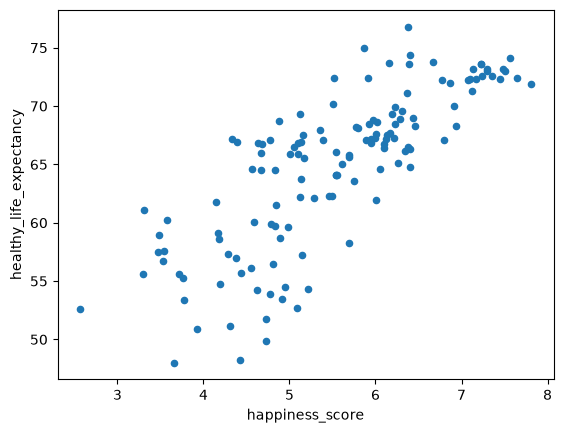

In [28]:
# Write your code here
merged_data.plot.scatter(x='happiness_score', y='healthy_life_expectancy')

Feel free to continue the exploration of the dataset! We'll release the solutions next week.

----
Enjoy EPFL and be happy, next year Switzerland must be #1.